In [1]:
pip install yfinance

In [2]:
import yfinance as yf

In [3]:
from datetime import datetime
end = datetime.now()
start = datetime(end.year -20 ,end.month ,end.day);

In [4]:
stock ="GOOG"
google_data = yf.download(stock,start,end)


/tmp/ipykernel_6683/3225654724.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  google_data = yf.download(stock,start,end)
[*********************100%***********************]  1 of 1 completed


In [5]:
google_data.shape

(5031, 5)

In [9]:
google_data

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2006-04-24,10.882034,10.985789,10.783712,10.854859,354780840
2006-04-25,10.552485,10.895374,10.523829,10.860542,384194678
2006-04-26,10.523088,10.623633,10.462811,10.566815,292203159
2006-04-27,10.376348,10.546309,10.360536,10.447494,334766100
2006-04-28,10.324719,10.517162,10.284205,10.341765,297964674
...,...,...,...,...,...
2026-04-16,332.769989,337.380005,331.649994,335.850006,13949600
2026-04-17,339.399994,339.984985,333.290009,334.429993,19683800


In [6]:
google_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
count,5031.000000,5031.000000,5031.000000,5031.000000,5.031000e+03
mean,63.137237,63.794220,62.442133,63.100871,8.071983e+07
std,65.911478,66.638565,65.108297,65.852055,8.944795e+07
min,6.359753,6.654470,6.109256,6.485001,1.584340e+05
25%,14.651099,14.774618,14.532890,14.657027,2.468200e+07
50%,36.470577,36.672919,36.135578,36.289066,3.964800e+07
75%,94.252438,95.585252,93.302984,94.266079,1.037775e+08
max,344.657196,349.903504,338.351644,348.269676,9.349835e+08


In [7]:
google_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5031 entries, 2006-04-24 to 2026-04-22
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GOOG)   5031 non-null   float64
 1   (High, GOOG)    5031 non-null   float64
 2   (Low, GOOG)     5031 non-null   float64
 3   (Open, GOOG)    5031 non-null   float64
 4   (Volume, GOOG)  5031 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 235.8 KB


In [10]:
google_data.isna().sum ()

,,0
Price,Ticker,
Close,GOOG,0
High,GOOG,0
Low,GOOG,0
Open,GOOG,0
Volume,GOOG,0


In [11]:

import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'Closing price of Google data')

<Figure size 1500x500 with 0 Axes>

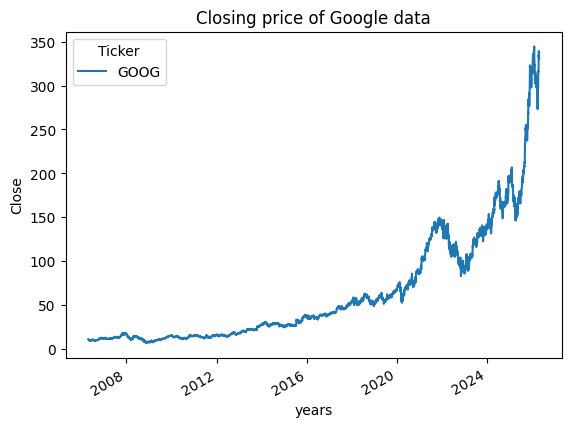

In [12]:

plt.figure(figsize = (15,5))
google_data['Close'].plot()
plt.xlabel("years")
plt.ylabel("Close")
plt.title("Closing price of Google data")

In [15]:
def plot_graph(figsize, values, column_name):
    plt.figure()
    values.plot(figsize = figsize)
    plt.xlabel("years")
    plt.ylabel(column_name)
    plt.title(f"{column_name} of Google data")

In [13]:
google_data.columns

MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])

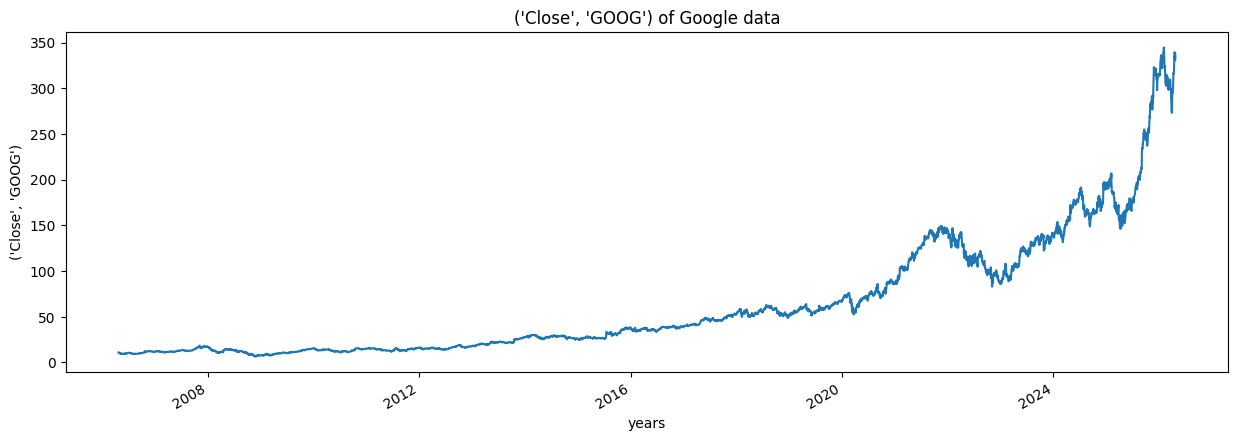

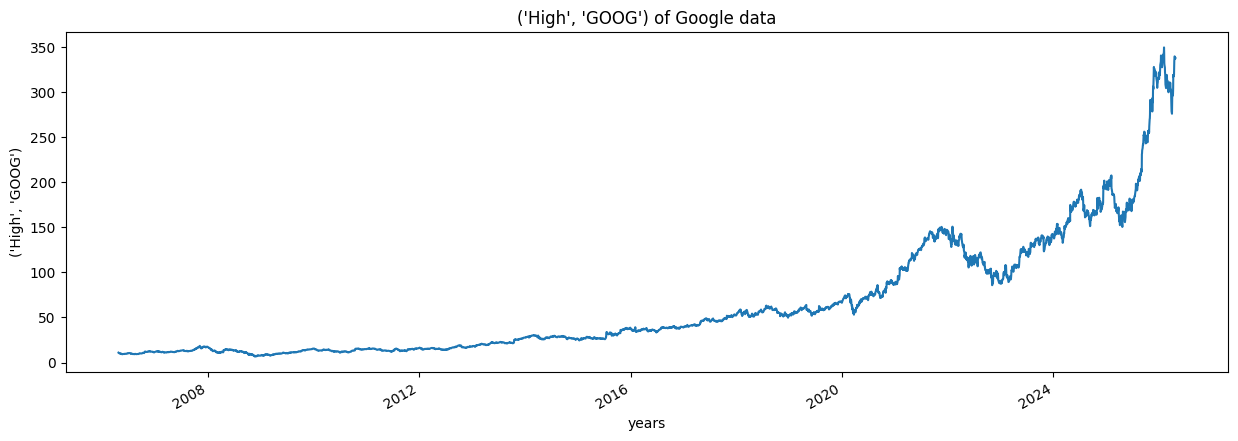

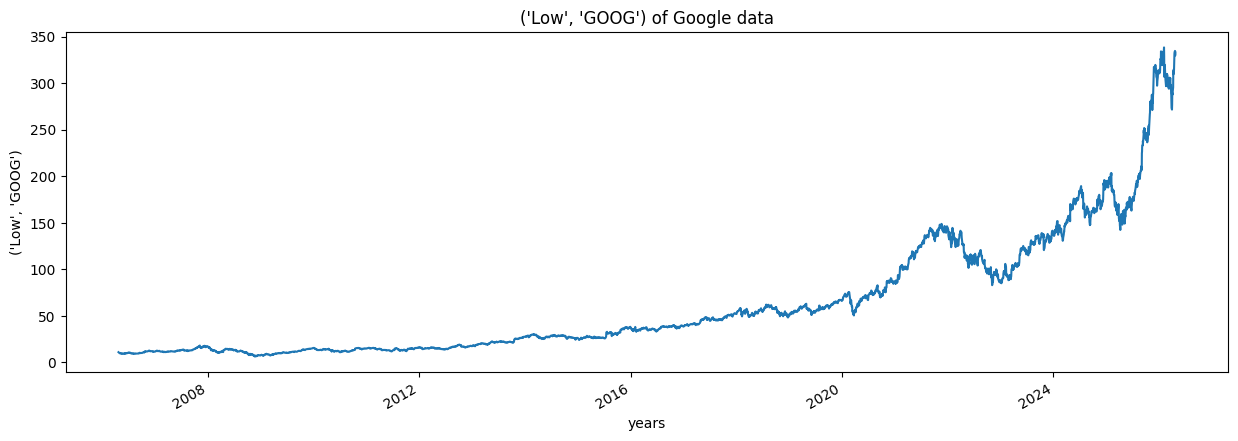

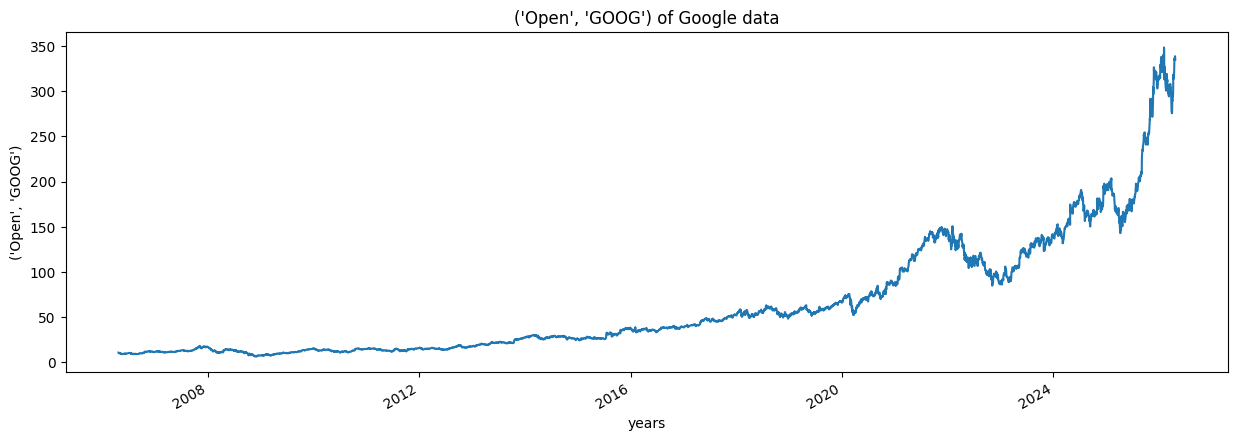

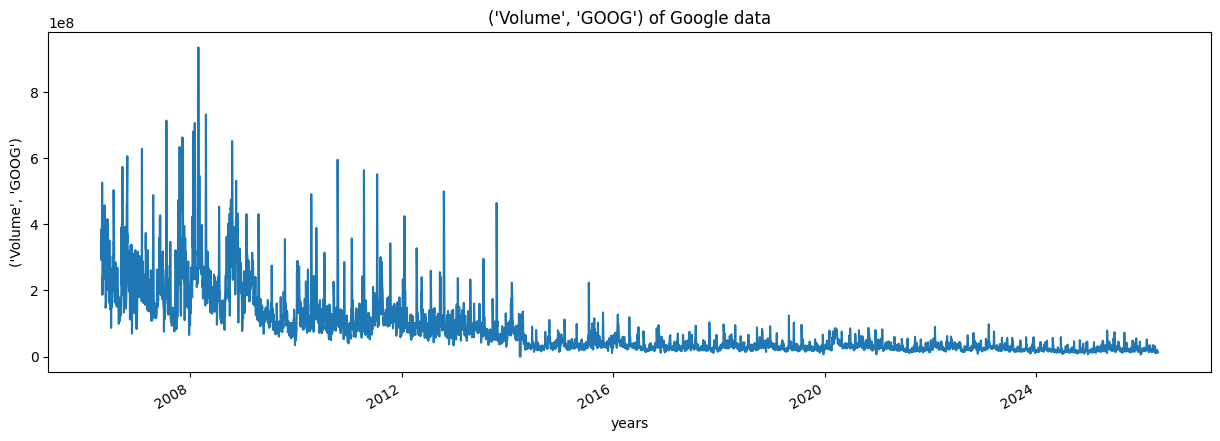

In [16]:
for column in google_data.columns:
    plot_graph((15,5),google_data[column], column)

In [ ]:
# 10, 20, 30, 40, 50, 60, 70, 80, 90, 100

# MA for 5 days ==> null null null null 30 40 50 60 70 80

In [17]:
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_data[1:6])/5)

40.0


In [18]:
import pandas as pd
data = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
data.head()

,0
0,10
1,20
2,30
3,40
4,50


In [19]:
data['MA'] = data.rolling(5).mean()
data

,0,MA
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


In [20]:
for i in range(2004,2025):
    print(i,list(google_data.index.year).count(i))

2004 0
2005 0
2006 175
2007 251
2008 253
2009 252
2010 252
2011 252
2012 250
2013 252
2014 252
2015 252
2016 252
2017 251
2018 251
2019 252
2020 253
2021 252
2022 251
2023 250
2024 252


In [22]:
google_data['MA_for_250_days'] = google_data['Close'].rolling(250).mean()

In [23]:
google_data['MA_for_250_days'][0:250].tail()


,MA_for_250_days
Date,
2007-04-16,NaN
2007-04-17,NaN
2007-04-18,NaN
2007-04-19,NaN
2007-04-20,10.723013


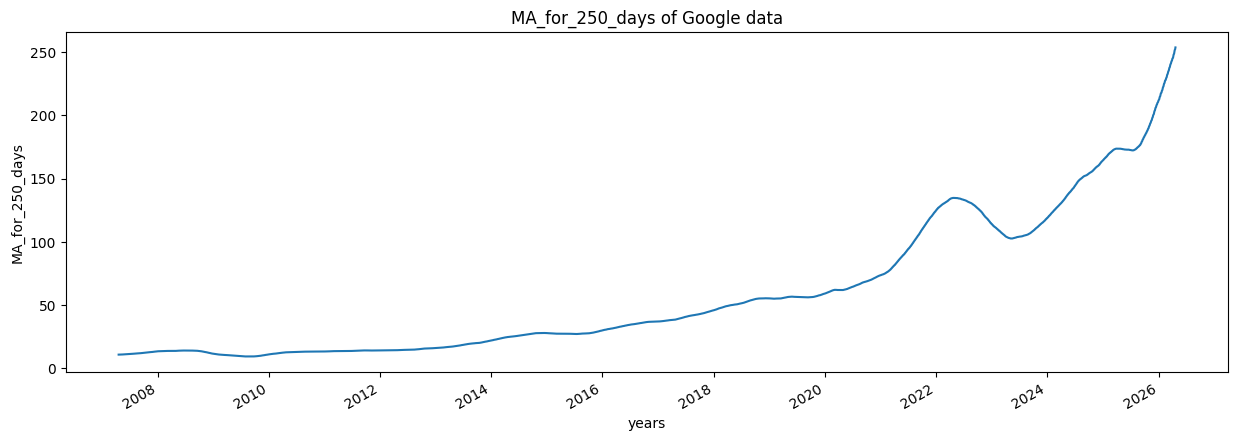

In [24]:
plot_graph((15,5), google_data['MA_for_250_days'], 'MA_for_250_days')

<Figure size 640x480 with 0 Axes>

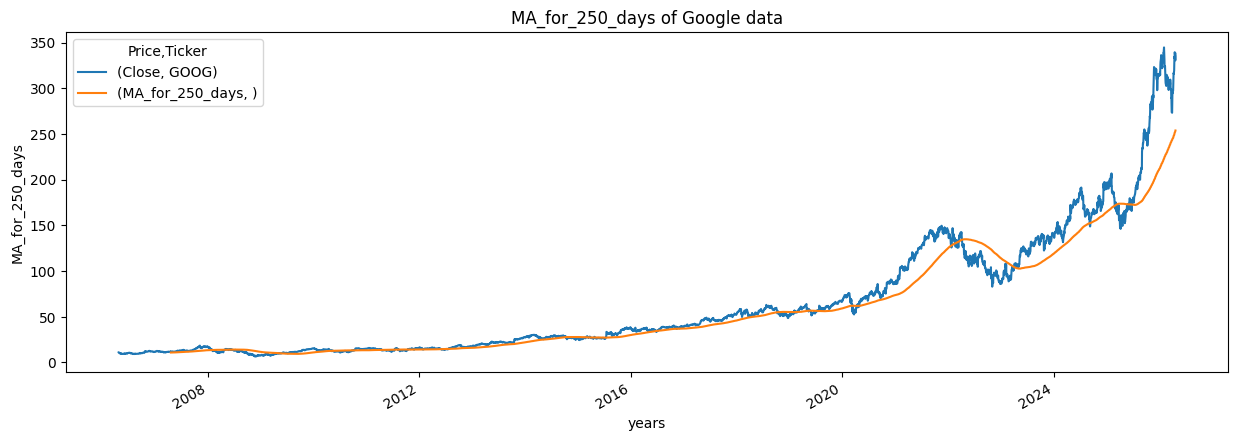

In [26]:
plot_graph((15,5), google_data[['Close','MA_for_250_days']], 'MA_for_250_days')

<Figure size 640x480 with 0 Axes>

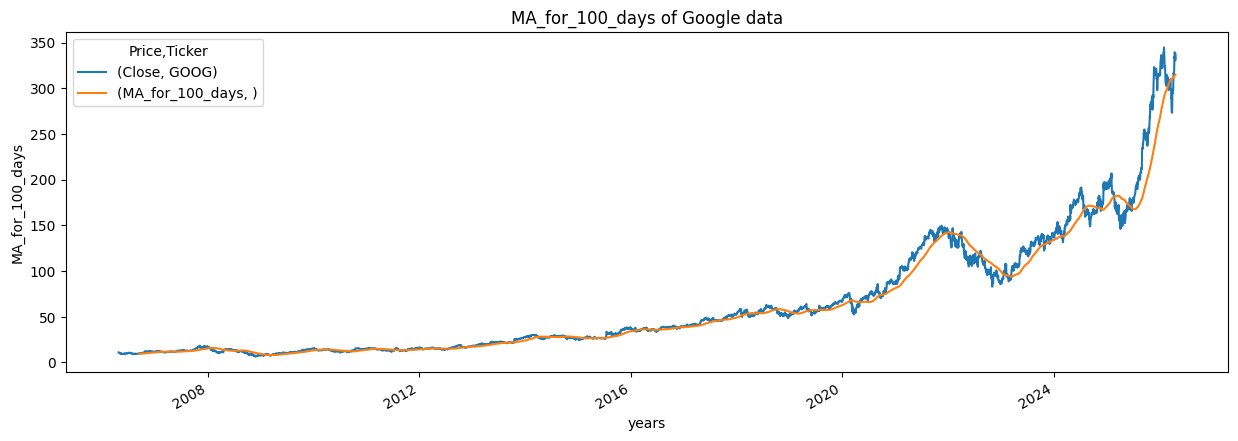

In [28]:

google_data['MA_for_100_days'] = google_data['Close'].rolling(100).mean()
plot_graph((15,5), google_data[['Close','MA_for_100_days']], 'MA_for_100_days')

<Figure size 640x480 with 0 Axes>

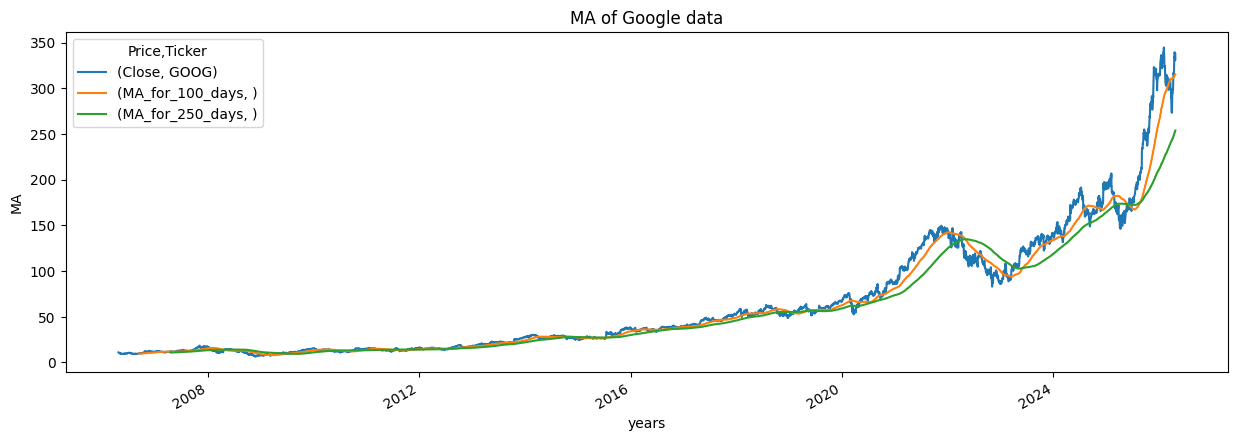

In [29]:
plot_graph((15,5), google_data[['Close','MA_for_100_days', 'MA_for_250_days']], 'MA')

In [31]:
google_data['percentage_change_cp'] = google_data['Close'].pct_change()
google_data[['Close','percentage_change_cp']].head()

Price,Close,percentage_change_cp
Ticker,GOOG,
Date,,
2006-04-24,10.882034,NaN
2006-04-25,10.552485,NaN
2006-04-26,10.523088,NaN
2006-04-27,10.376348,NaN
2006-04-28,10.324719,NaN


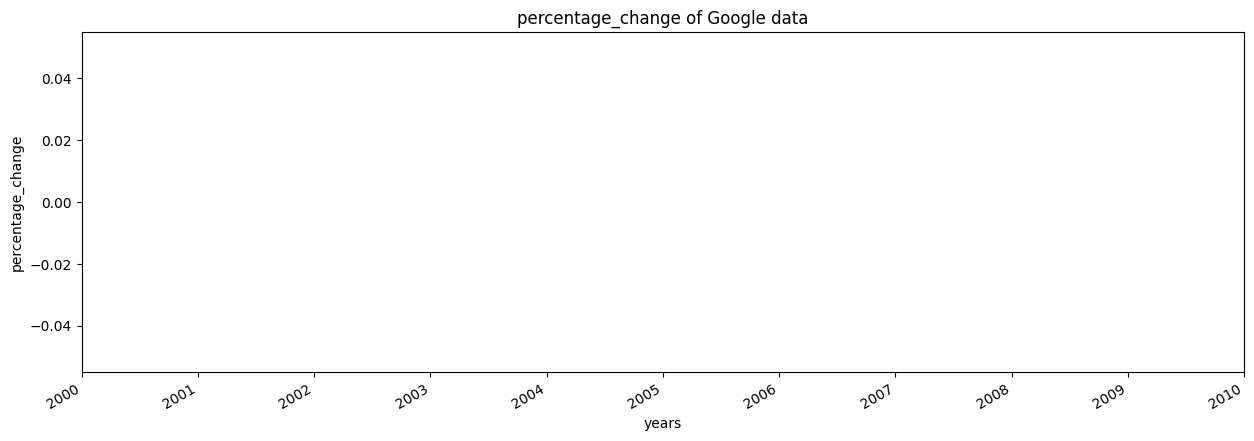

In [33]:

plot_graph((15,5), google_data['percentage_change_cp'], 'percentage_change')

In [35]:
Adj_close_price = google_data[['Close']]

In [36]:
max(Adj_close_price.values),min(Adj_close_price.values)

(array([344.65719604]), array([6.35975266]))

In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(Adj_close_price)
scaled_data

array([[0.01336777],
       [0.01239363],
       [0.01230673],
       ...,
       [0.97263591],
       [0.95806296],
       [0.97952339]])

In [38]:
len(scaled_data)

5031

In [39]:
x_data = []
y_data = []

for i in range(100, len(scaled_data)):
    x_data.append(scaled_data[i-100:i])
    y_data.append(scaled_data[i])

import numpy as np
x_data, y_data = np.array(x_data), np.array(y_data)

In [40]:
x_data[0],y_data[0]

(array([[0.01336777],
        [0.01239363],
        [0.01230673],
        [0.01187297],
        [0.01172036],
        [0.01032997],
        [0.01003058],
        [0.00998457],
        [0.01002692],
        [0.00999407],
        [0.01002912],
        [0.01105291],
        [0.01062791],
        [0.00946099],
        [0.00852117],
        [0.00867233],
        [0.00831451],
        [0.00854819],
        [0.00829188],
        [0.00822104],
        [0.00828896],
        [0.00862705],
        [0.0090411 ],
        [0.00916816],
        [0.00904841],
        [0.00836125],
        [0.00835248],
        [0.00914115],
        [0.00890892],
        [0.00854381],
        [0.00967933],
        [0.00942521],
        [0.00992104],
        [0.00942959],
        [0.00906228],
        [0.00942594],
        [0.0092704 ],
        [0.00975309],
        [0.00973118],
        [0.00954424],
        [0.0094734 ],
        [0.01056585],
        [0.01040665],
        [0.0107652 ],
        [0.01071846],
        [0

In [41]:
int(len(x_data)*0.7)

3451

In [42]:
4908-100-int(len(x_data)*0.7)

1357

In [43]:
splitting_len = int(len(x_data)*0.7)
x_train = x_data[:splitting_len]
y_train = y_data[:splitting_len]

x_test = x_data[splitting_len:]
y_test = y_data[splitting_len:]

In [44]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(3451, 100, 1)
(3451, 1)
(1480, 100, 1)
(1480, 1)


In [45]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [46]:
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [47]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [48]:
model.fit(x_train, y_train, batch_size=1, epochs = 2)

Epoch 1/2
3451/3451 ━━━━━━━━━━━━━━━━━━━━ 174s 50ms/step - loss: 5.7048e-05
Epoch 2/2
3451/3451 ━━━━━━━━━━━━━━━━━━━━ 187s 45ms/step - loss: 2.8246e-05


In [49]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [50]:
predictions = model.predict(x_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step


In [51]:
predictions

array([[0.18994921],
       [0.19091791],
       [0.19126704],
       ...,
       [0.93748766],
       [0.9361313 ],
       [0.92627525]], dtype=float32)

In [52]:
inv_predictions = scaler.inverse_transform(predictions)
inv_predictions

array([[ 70.61909],
       [ 70.94679],
       [ 71.0649 ],
       ...,
       [323.50943],
       [323.05057],
       [319.7163 ]], dtype=float32)

In [53]:
inv_y_test = scaler.inverse_transform(y_test)
inv_y_test

array([[ 71.37501526],
       [ 71.23416901],
       [ 70.03401947],
       ...,
       [335.3999939 ],
       [330.47000122],
       [337.73001099]])

In [54]:
rmse = np.sqrt(np.mean( (inv_predictions - inv_y_test)**2))

In [ ]:
rmse

In [55]:
ploting_data = pd.DataFrame(
 {
  'original_test_data': inv_y_test.reshape(-1),
    'predictions': inv_predictions.reshape(-1)
 } ,
    index = google_data.index[splitting_len+100:]
)
ploting_data.head()

,original_test_data,predictions
Date,,
2020-06-02,71.375015,70.619087
2020-06-03,71.234169,70.946793
2020-06-04,70.034019,71.064903
2020-06-05,71.333847,70.504936
2020-06-08,71.741493,70.724983


<Figure size 640x480 with 0 Axes>

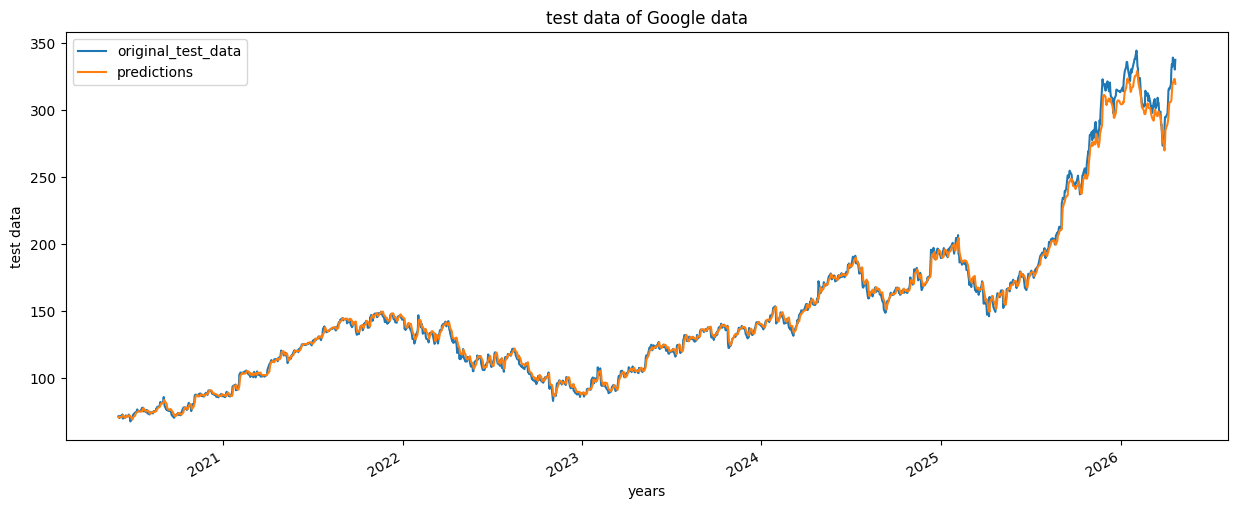

In [56]:
plot_graph((15,6), ploting_data, 'test data')

<Figure size 640x480 with 0 Axes>

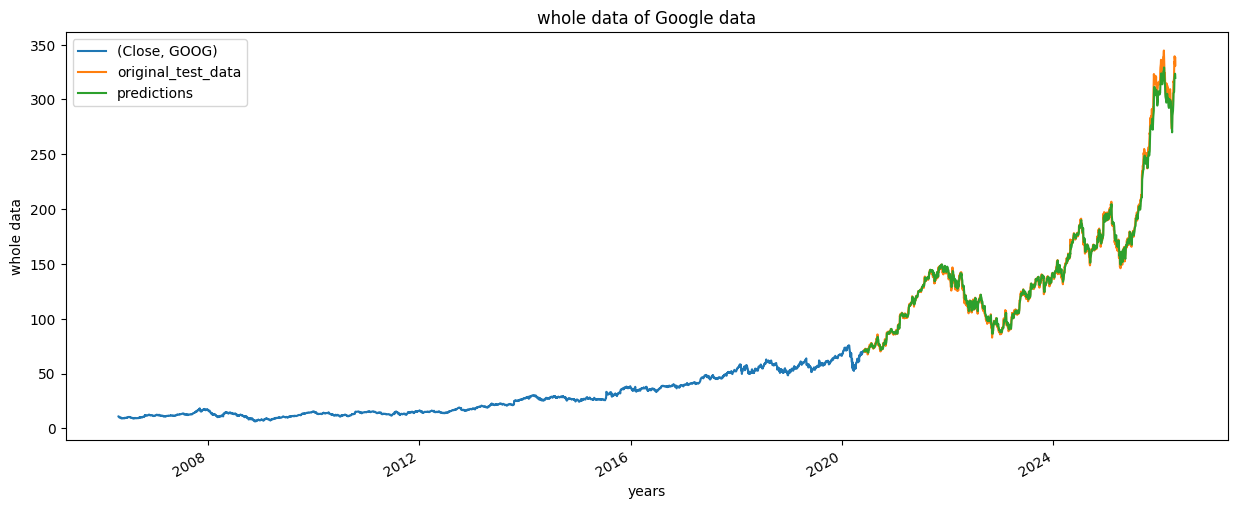

In [57]:
plot_graph((15,6), pd.concat([Adj_close_price[:splitting_len+100],ploting_data], axis=0), 'whole data')

In [58]:
model.save("Latest_stock_price_model.keras")